## 1. Data Loading, inspection and preparation 

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
import warnings
import ssl
import pandas as pd

from keras import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, RandomFlip, RandomRotation, RandomZoom


I0000 00:00:1775211195.716475    9957 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Configuration set-up

In [2]:
warnings.filterwarnings("ignore")
ssl._create_default_https_context = ssl._create_unverified_context

# Select TensorFlow's backend
os.environ["KERAS_BACKEND"] = "tensorflow"

# Select hardware accelerator (GPU if available, otherwise CPU)
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    details = tf.config.experimental.get_device_details(gpu_devices[0])
    gpu_name = details.get("device_name", "Name not found")
    print(f"Available GPU: {gpu_name}")
else:
    print("No GPU detected.")

print(f"Keras version: {keras.__version__}")

seed = 42
keras.utils.set_random_seed(seed)
np.random.seed(seed)

Available GPU: NVIDIA GeForce GTX 1660 Ti
Keras version: 3.14.0


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

Import the dataset using tenserflow dataset:

In [4]:
DATA_DIR = "./data"
IMG_SHAPE = (224, 224)
os.makedirs(DATA_DIR, exist_ok=True)

dataset_split = ["train[:80%]", "train[80%:]", "test"]
(train_split, val_split, test_data), info = tfds.load(
    "oxford_iiit_pet",
    split=dataset_split,
    as_supervised=True,
    with_info=True,
    data_dir=DATA_DIR
)

I0000 00:00:1775211199.320360    9957 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4069 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Now we have a "lazy" object that we need to convert in a usable dataset:

In [5]:
def dataset_to_numpy(dataset, img_size):
    images = []
    labels = []
    
    for img, label in tfds.as_numpy(dataset):
        img_resized = tf.image.resize(img, img_size).numpy().astype(np.uint8)
        images.append(img_resized)
        labels.append(label)

    return np.array(images), np.array(labels)

x_train, y_train = dataset_to_numpy(train_split, img_size=IMG_SHAPE)
x_val, y_val     = dataset_to_numpy(val_split, img_size=IMG_SHAPE)
x_test, y_test   = dataset_to_numpy(test_data, img_size=IMG_SHAPE)


I0000 00:00:1775211199.575861   10047 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Check the class distribution in every split:

In [6]:
_, train_count = np.unique(y_train, return_counts=True)
_, validation_count = np.unique(y_val, return_counts=True)
_, test_count = np.unique(y_test, return_counts=True)

distribution = pd.DataFrame({
    "Class": info.features["label"].names,
    "Train%": (train_count / len(y_train)) * 100,
    "Validation%": (validation_count / len(y_val)) * 100,
    "Test%": (test_count / len(y_test)) * 100,
    "Train": train_count,
    "Validation": validation_count,
    "Test": test_count,
})
distribution["Total count"] = distribution["Train"] + distribution["Validation"] + distribution["Test"]
distribution = distribution.round(2)

print(f"Perfectly balanced dataset distribution if ~={100/len(distribution):.2f}%:")
distribution

Perfectly balanced dataset distribution if ~=2.70%:


,Class,Train%,Validation%,Test%,Train,Validation,Test,Total count
0,Abyssinian,2.58,3.26,2.67,76,24,98,198
1,american_bulldog,2.79,2.45,2.73,82,18,100,200
2,american_pit_bull_terrier,2.96,1.77,2.73,87,13,100,200
3,basset_hound,2.72,2.72,2.73,80,20,100,200
4,beagle,2.82,2.31,2.73,83,17,100,200
5,Bengal,2.79,2.45,2.73,82,18,100,200
6,Birman,2.58,3.26,2.73,76,24,100,200
7,Bombay,2.62,2.58,2.40,77,19,88,184
8,boxer,2.58,3.26,2.70,76,24,99,199
9,British_Shorthair,2.75,2.58,2.73,81,19,100,200


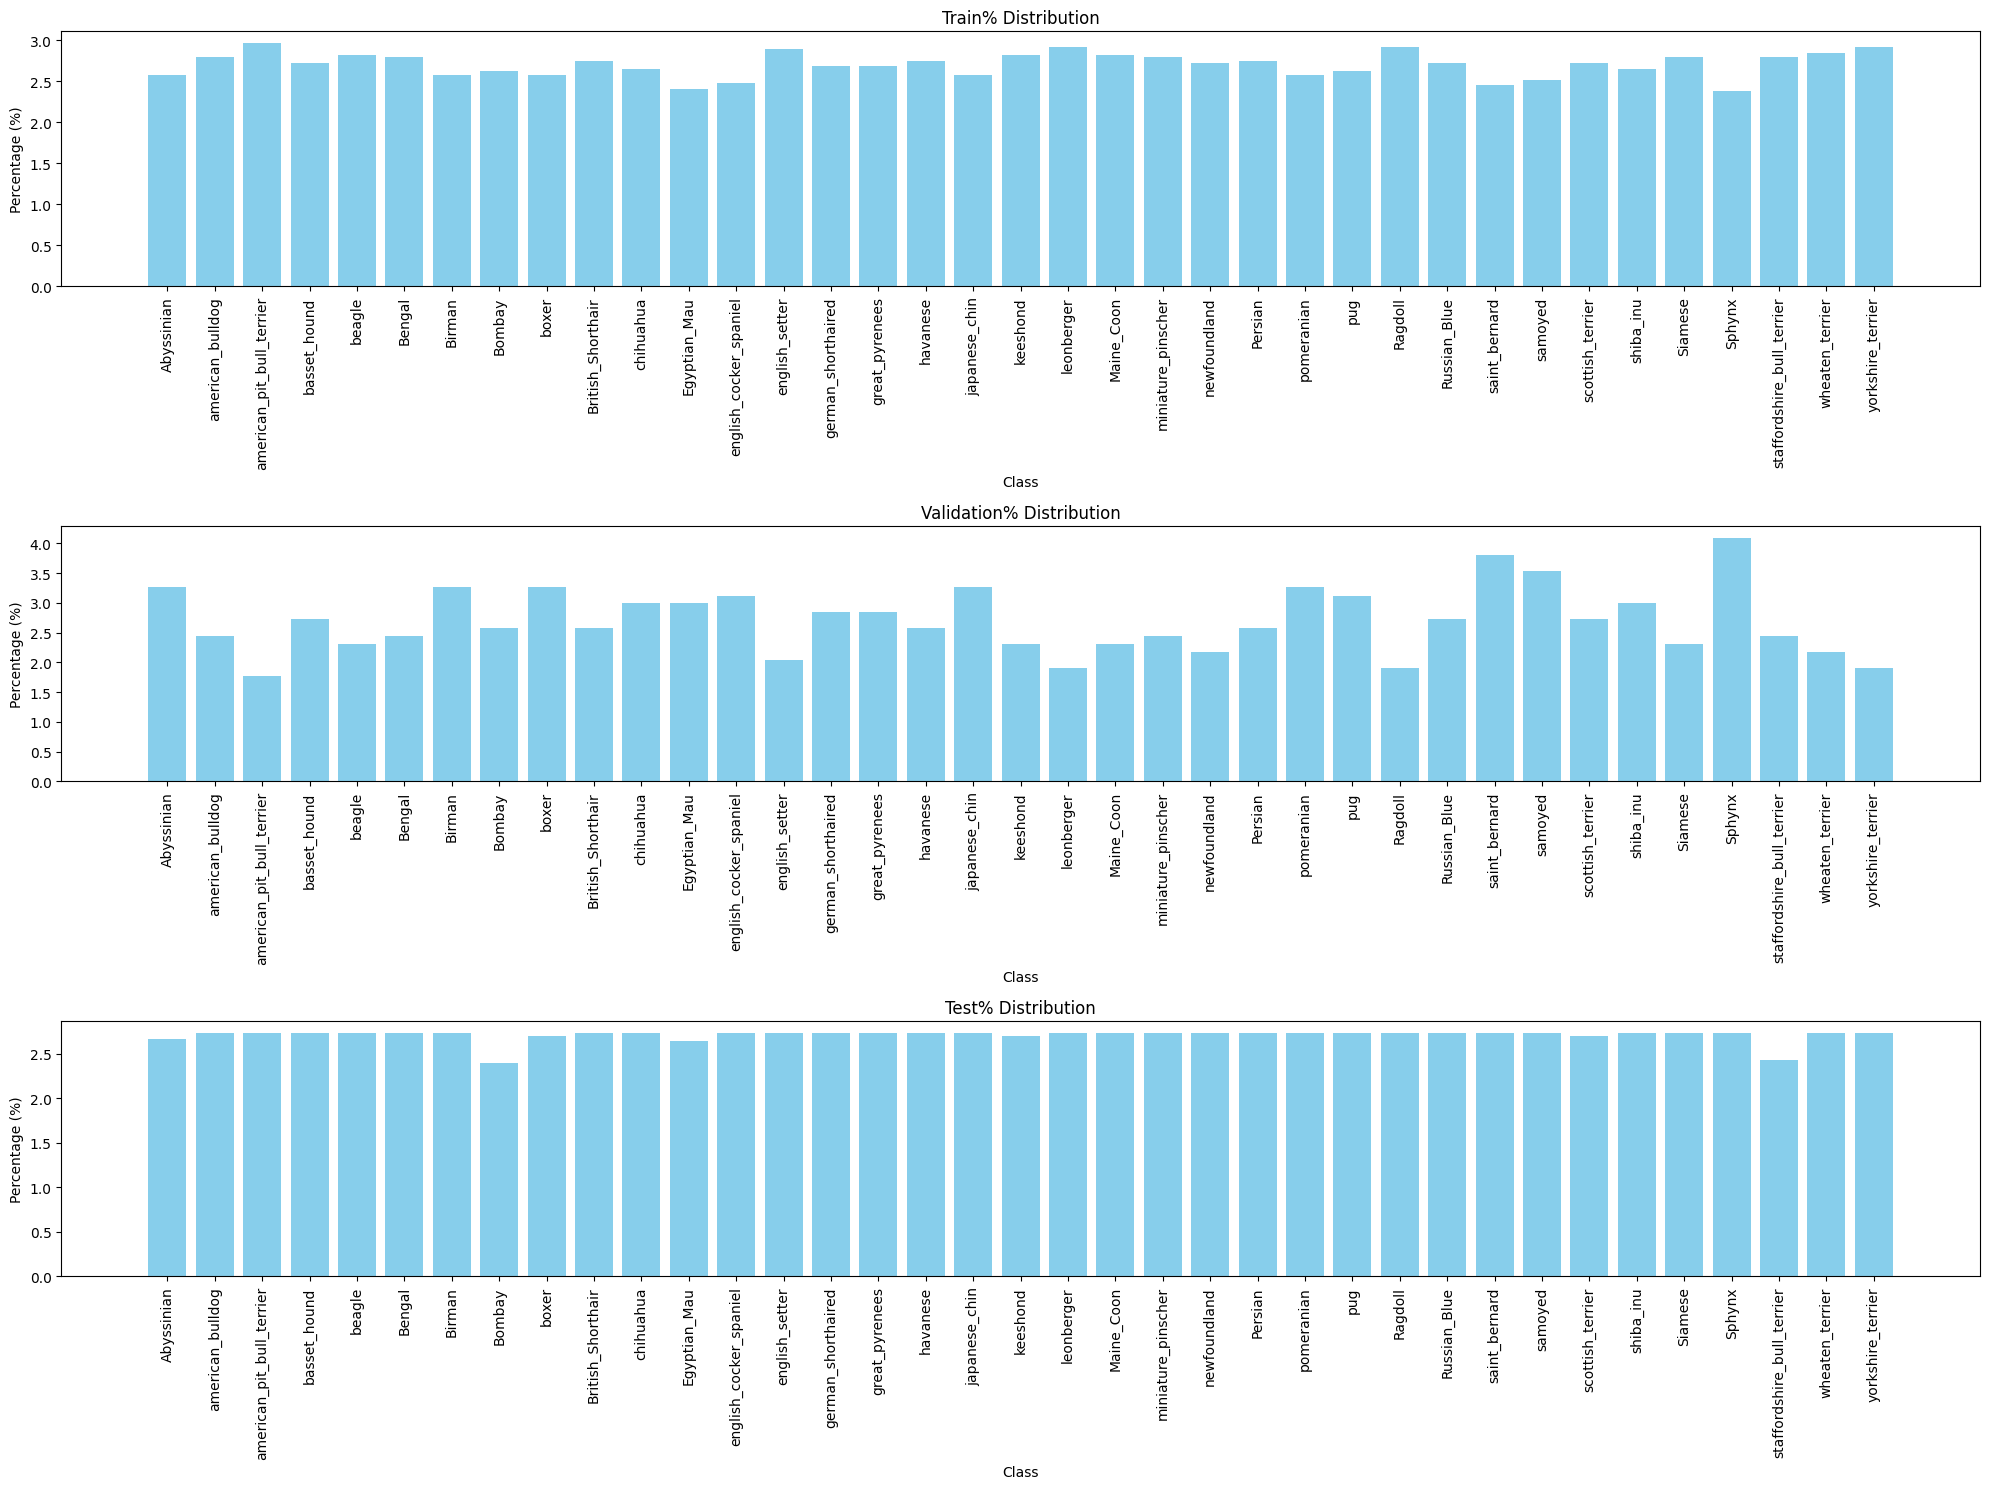

In [7]:
fig, ax = plt.subplots(3, 1, figsize=(20, 15))
ax = ax.flatten()

for idx in range(3):
    ax[idx].bar(distribution["Class"], distribution.iloc[:, idx + 1], color="skyblue")
    ax[idx].set_title(f"{distribution.columns[idx + 1]} Distribution")
    ax[idx].set_xlabel("Class")
    ax[idx].set_ylabel("Percentage (%)")
    ax[idx].set_xticklabels(distribution["Class"], rotation=90)

plt.tight_layout()
plt.show()

Let's get the "labels" for further usage:

In [8]:
labels = {i: label for i, label in enumerate(info.features["label"].names)}
#labels 

Let's check if the operation done so far are correct:

In [9]:
n_train, w_train, h_train, channels = x_train.shape
n_test, w_test, h_test, channels_test = x_test.shape
n_classes = len(np.unique(y_train))

print(f"Number of classes: {n_classes}\n")
print(f"There are {n_train} samples in the training set, with size ({w_train},{h_train}).")
print(f"There are {n_test}  samples in the test set with, size    ({w_test},{h_test}).\n")
print(f"There are {n_classes} different classes.")

Number of classes: 37

There are 2944 samples in the training set, with size (224,224).
There are 3669  samples in the test set with, size    (224,224).

There are 37 different classes.


Let's normalize the data to improve the perfomance:

In [10]:
x_train = x_train.astype("float") / np.max(x_train)
x_test = x_test.astype("float") / np.max(x_test)
print(f"The new range of the images is [{x_train.min()},{x_train.max()}].")

input_shape = x_train.shape[1:]

The new range of the images is [0.0,1.0].


## 

## 2. Naive model implementation 

In [11]:
model = Sequential([
    # Input layer.
        Input(shape = input_shape),

        Conv2D(filters = 32, kernel_size = (3, 3), activation = "relu", padding = 'same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Conv2D(filters = 64, kernel_size = (3, 3), activation = "relu", padding = 'same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Conv2D(filters = 128, kernel_size = (3, 3), activation = "relu", padding = 'same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        Flatten(),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.5),
        Dense(units = n_classes, activation = "softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,795,045 (98.40 MB)

 Trainable params: 25,794,085 (98.40 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
from keras.optimizers import Adam
from keras.losses import SparseCategoricalCrossentropy

def preprocess(img, label):
    img = tf.image.resize(img, IMG_SHAPE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

batch_size = 32
epochs = 6

train_ds = train_split.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE) \
                       .shuffle(500) \
                       .batch(batch_size) \
                       .prefetch(tf.data.AUTOTUNE)

val_ds   = val_split.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE) \
                    .batch(batch_size) \
                    .prefetch(tf.data.AUTOTUNE)

test_ds  = test_data.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE) \
                    .batch(batch_size) \
                    .prefetch(tf.data.AUTOTUNE)

opt      = Adam(learning_rate=1e-3)
loss_fcn = SparseCategoricalCrossentropy()

model.compile(loss=loss_fcn, optimizer=opt, metrics=["accuracy"])
model.fit(train_ds, epochs=epochs, validation_data=val_ds)

Epoch 1/6


I0000 00:00:1775211221.462157   10030 service.cc:153] XLA service 0x7eb2bc006da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775211221.462174   10030 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.6.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775211221.542079   10030 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775211221.960413   10030 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775211222.104700   10030 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_63107__.65


 2/92 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.0234 - loss: 5.2191  

I0000 00:00:1775211231.040176   10030 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - accuracy: 0.0744 - loss: 4.1568 - val_accuracy: 0.0272 - val_loss: 19.3155
Epoch 2/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.1281 - loss: 3.5442 - val_accuracy: 0.0285 - val_loss: 15.1341
Epoch 3/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.1732 - loss: 3.2694 - val_accuracy: 0.0394 - val_loss: 10.5593
Epoch 4/6
 2/92 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.3281 - loss: 2.4838  

W0000 00:00:1775211257.529094   10374 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.2707 - loss: 2.7080 - val_accuracy: 0.0408 - val_loss: 5.8853
Epoch 5/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.4154 - loss: 2.1125 - val_accuracy: 0.0666 - val_loss: 4.7815
Epoch 6/6
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.5048 - loss: 1.7324 - val_accuracy: 0.0965 - val_loss: 3.9138


115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.0878 - loss: 3.9158
The test loss is 3.9158, the test accuracy is 0.0878.
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
Test output shape: (3669, 37)


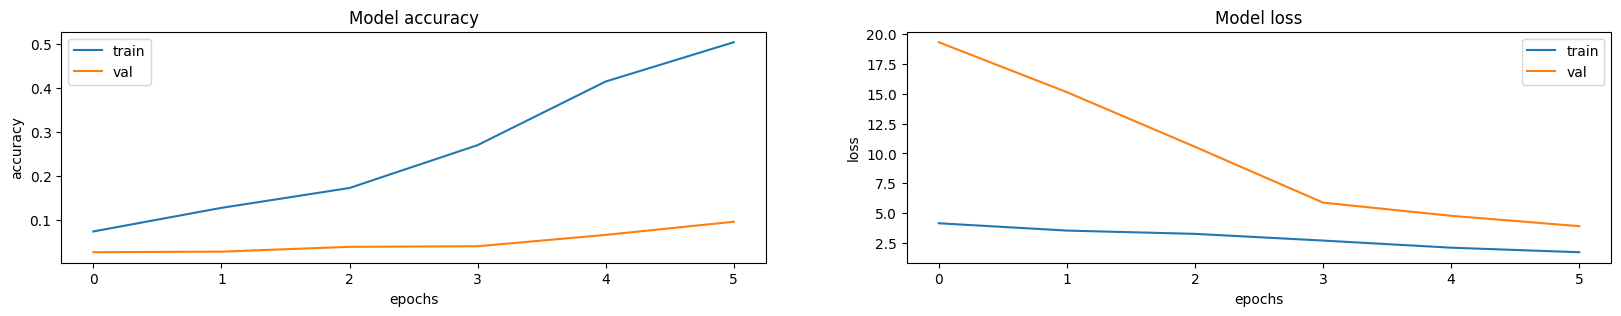

In [13]:
plt.figure(figsize=(20, 3))
for i, metric in enumerate(["accuracy", "loss"]):
    plt.subplot(1, 2, i + 1) 
    plt.plot(model.history.history[metric])
    plt.plot(model.history.history["val_" + metric])
    plt.title("Model {}".format(metric))
    plt.xlabel("epochs")
    plt.ylabel(metric)
    plt.legend(["train", "val"])

test_loss, test_metric = model.evaluate(test_ds, verbose=1)
print(f"The test loss is {test_loss:.4f}, the test accuracy is {test_metric:.4f}.")

pred = model.predict(test_ds)
print("Test output shape: {}".format(pred.shape))

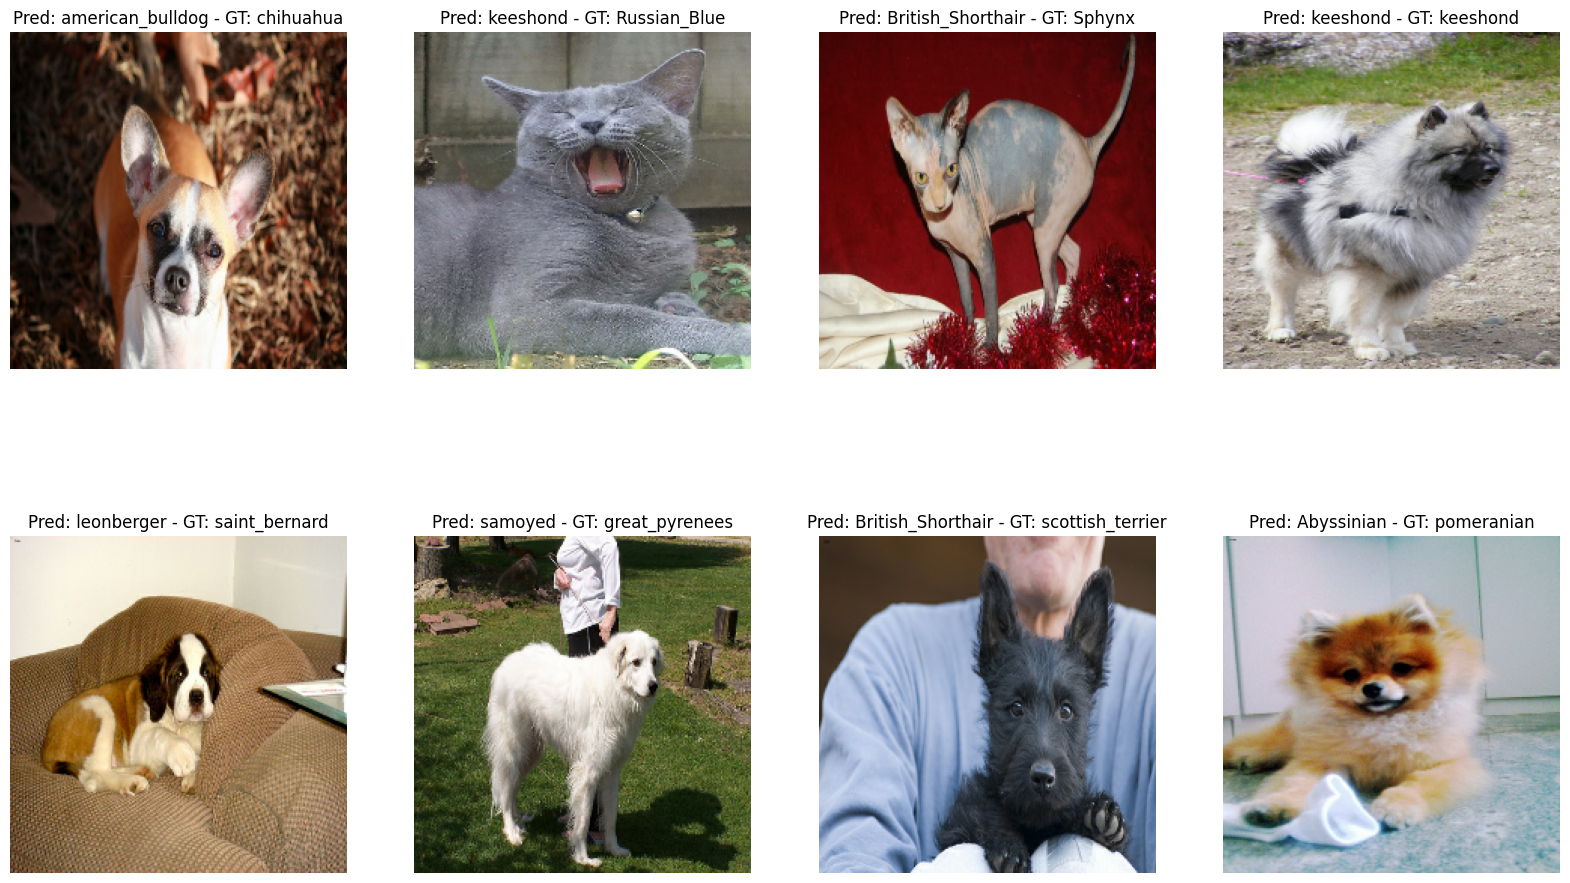

In [14]:
pred = np.argmax(pred, axis=-1)

# Estrai immagini e label da test_ds per la visualizzazione
x_test_vis, y_test_vis = [], []
for imgs, lbls in test_ds:
    x_test_vis.append(imgs.numpy())
    y_test_vis.append(lbls.numpy())
x_test_vis = np.concatenate(x_test_vis, axis=0)
y_test_vis = np.concatenate(y_test_vis, axis=0)

plt.figure(figsize=(20, 12))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    rand_idx = np.random.randint(0, x_test_vis.shape[0])
    plt.axis('off')
    plt.title(f"Pred: {labels[pred[rand_idx]]} - GT: {labels[y_test_vis[rand_idx]]}")
    plt.imshow(x_test_vis[rand_idx])
plt.show()